<a href="https://colab.research.google.com/github/c-marq/CAP3321C-Data-Wrangling/blob/main/[PATH]/case-study-airports-starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airports Case Study: Section 1

**CAP3321C Data Wrangling** | Group lab | Miami Dade College

**Scenario.** You are an analyst employed by the U.S. Transportation Security Administration (TSA). Your boss has asked you to produce a report that answers five questions about insurance claims filed against airports in the U.S.

**How this notebook works.** The setup cell loads the data. After that, every question has three cells: a heading, a code cell for your analysis, and a markdown cell where you write what the table or plot tells you. Your boss reads the markdown, not the code. Keep this notebook clean; you will extend it for your final (section 2 of this case study).

**Notebook requirements**
- A markdown heading for every question
- A table or plot that answers it
- A short written summary under each answer
- Comments or markdown explaining any cleaning decision and any code that is not obvious

**Group Members:**
- Name 1: Yofrank Martinez
- Name 2: Jan Zika
- Name 3: Daniel Soriano
- Name 4: Diego Garcia

**Roles:** Lead Coder / Data Interpreter / Presenter / QA Reviewer

## Setup

In [41]:
# Run this cell. Do not modify.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/c-marq/CAP3321C-Data-Wrangling/main/data/tsa_claims1.csv"
claims_df = pd.read_csv(url, low_memory=False)

print(claims_df.shape)
claims_df.head()

#We have 13 columns originally and 94848 rows

(94848, 13)


,Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,0909802M,4-Jan-02,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,350.00,Approved,350.00,Approve in Full
1,0202445M,4-Feb-02,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,278.88,Settled,227.92,Settle
2,0909816M,7-Feb-02,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),50.00,Approved,50.00,Approve in Full
3,2005032379513,18-Feb-02,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,84.79,Approved,84.79,Approve in Full
4,2005032479636,18-Feb-02,2/17/2005 0:00,CAK,Akron-Canton Regional,Air Tran Airlines(do not use),Passenger Property Loss,Checked Baggage,Other,459.01,Settled,227.00,Settle


**Checkpoint.** The shape should be `(94848, 13)`. If it is not, re-run the setup cell.

## Explore and clean the data

Before answering anything, get to know the file. Use `info()`, `describe()`, `isna().sum()`, and `value_counts()` on the columns you plan to use. Then make your cleaning decisions and **explain them in the markdown cell below the code**.

In [17]:
# Explore: run info(), describe(), isna().sum(), and value_counts() on the columns you care about
# info
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94848 entries, 0 to 94847
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Claim Number   94848 non-null  object 
 1   Date Received  94848 non-null  object 
 2   Incident Date  94848 non-null  object 
 3   Airport Code   94848 non-null  object 
 4   Airport Name   94848 non-null  object 
 5   Airline Name   94848 non-null  object 
 6   Claim Type     94848 non-null  object 
 7   Claim Site     94848 non-null  object 
 8   Item           94848 non-null  object 
 9   Claim Amount   94848 non-null  float64
 10  Status         94848 non-null  object 
 11  Close Amount   94848 non-null  float64
 12  Disposition    94848 non-null  object 
dtypes: float64(2), object(11)
memory usage: 9.4+ MB


In [18]:
#describe
claims_df.describe()

,Claim Amount,Close Amount
count,9.484800e+04,94848.000000
mean,3.634831e+03,89.046256
std,5.249437e+05,882.058837
min,0.000000e+00,0.000000
25%,6.500000e+01,0.000000
50%,1.836900e+02,0.000000
75%,4.806425e+02,61.972500
max,1.250000e+08,250000.000000


In [19]:
claims_df.describe().T
#possible outlier in claim amount (max is at an absurd value)

,count,mean,std,min,25%,50%,75%,max
Claim Amount,94848.0,3634.830998,524943.661162,0.0,65.0,183.69,480.6425,125000000.0
Close Amount,94848.0,89.046256,882.058837,0.0,0.0,0.00,61.9725,250000.0


In [20]:
#isna
claims_df.isna().sum()

,0
Claim Number,0
Date Received,0
Incident Date,0
Airport Code,0
Airport Name,0
Airline Name,0
Claim Type,0
Claim Site,0
Item,0
Claim Amount,0


In [21]:
#value counts
claims_df.value_counts()

,,,,,,,,,,,,,count
Claim Number,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition,
27123,15-Nov-02,10/30/2002 0:00,PDX,Portland International,Delta Air Lines,Passenger Property Loss,Checkpoint,Jewelry - Fine,225.00,Approved,225.00,Approve in Full,1
26879,24-Jan-03,12/31/2002 0:00,DSM,Des Moines International,Northwest Airlines,Passenger Property Loss,Checked Baggage,Other,35.00,Approved,35.00,Approve in Full,1
26842,17-Jan-03,12/28/2002 0:00,TPA,Tampa International,Delta Air Lines,Property Damage,Checked Baggage,Luggage (all types including footlockers),57.23,Approved,57.00,Approve in Full,1
26246,17-Jan-03,12/18/2002 0:00,AUS,Austin-Bergstrom International Airport,Southwest Airlines,Property Damage,Checkpoint,DVD/CD Players,35.00,Approved,35.00,Approve in Full,1
26221,18-Nov-02,10/26/2002 0:00,PHL,Philadelphia International Airport,USAir,Passenger Property Loss,Checkpoint,Clothing - Shoes; belts; accessories; etc.,500.00,Approved,500.00,Approve in Full,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0105052M,5-Jan-04,11/12/2003 0:00,SMF,Sacramento International Airport,Frontier Airlines,Passenger Property Loss,Checked Baggage,Cameras - Digital,450.00,Denied,0.00,Deny,1
0105050M,5-Jan-04,11/3/2003 0:00,OAK,Metropolitan Oakland International,Southwest Airlines,Property Damage,Checked Baggage,Other,64.95,Approved,64.95,Approve in Full,1
0105003M,5-Jan-04,7/29/2003 0:00,LAX,Los Angeles International Airport,UAL,Property Damage,Checked Baggage,Other,470.00,Approved,470.00,Approve in Full,1


In [22]:
claims_df.nunique()
#we have 4 claim sites, 6 claim types, 3 disposition types

,0
Claim Number,94848
Date Received,2014
Incident Date,3882
Airport Code,411
Airport Name,411
Airline Name,186
Claim Type,6
Claim Site,4
Item,3072
Claim Amount,27013


In [69]:
# Clean: apply any changes you decided on (drop rows, fix types, filter categories)

In [38]:
claims_df['Date Received'].dtype
#date type applied to Date Received column

dtype('<M8[ns]')

In [39]:
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94848 entries, 0 to 94847
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Claim Number   94848 non-null  object        
 1   Date Received  94848 non-null  datetime64[ns]
 2   Incident Date  94848 non-null  object        
 3   Airport Code   94848 non-null  object        
 4   Airport Name   94848 non-null  object        
 5   Airline Name   94848 non-null  object        
 6   Claim Type     94848 non-null  object        
 7   Claim Site     94848 non-null  object        
 8   Item           94848 non-null  object        
 9   Claim Amount   94848 non-null  float64       
 10  Status         94848 non-null  object        
 11  Close Amount   94848 non-null  float64       
 12  Disposition    94848 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(10)
memory usage: 9.4+ MB


In [40]:
claims_df.drop(columns=['Claim Number'])
#replaced claim number with actual numbers up until the max

,Date Received,Incident Date,Airport Code,Airport Name,Airline Name,Claim Type,Claim Site,Item,Claim Amount,Status,Close Amount,Disposition
0,2002-01-04,12/12/2002 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checkpoint,Other,350.00,Approved,350.00,Approve in Full
1,2002-02-04,11/26/2003 0:00,STL,Lambert St. Louis International,American Airlines,Property Damage,Checked Baggage,Cell Phones,278.88,Settled,227.92,Settle
2,2002-02-07,1/6/2003 0:00,MIA,Miami International Airport,American Airlines,Property Damage,Checkpoint,Luggage (all types including footlockers),50.00,Approved,50.00,Approve in Full
3,2002-02-18,2/5/2005 0:00,MCO,Orlando International Airport,Delta (Song),Property Damage,Checkpoint,Baby - Strollers; car seats; playpen; etc.,84.79,Approved,84.79,Approve in Full
4,2002-02-18,2/17/2005 0:00,CAK,Akron-Canton Regional,Air Tran Airlines(do not use),Passenger Property Loss,Checked Baggage,Other,459.01,Settled,227.00,Settle
...,...,...,...,...,...,...,...,...,...,...,...,...
94843,2009-12-31,12/14/2009 0:00,EWR,Newark International Airport,Continental Airlines,Property Damage,Checked Baggage,Luggage (all types including footlockers),175.90,Denied,0.00,Deny
94844,2009-12-31,12/17/2009 7:55,BWI,Baltimore/Washington Intl Thurgood Marshall,Southwest Airlines,Passenger Property Loss,Checked Baggage,Cell Phones (smartphone type-blackberry; iphon...,695.00,Denied,0.00,Deny
94845,2009-12-31,12/15/2009 0:00,SMF,Sacramento International Airport,Southwest Airlines,Passenger Property Loss,Checked Baggage,Locks,25.50,Denied,0.00,Deny
94846,2009-12-31,12/16/2009 10:00,ENV,Wendover Municipal Airport,Xtra Airways,Passenger Property Loss,Checked Baggage,Locks,20.00,Denied,0.00,Deny


**Things to look at in this dataset**
- Look at `value_counts()` for `Status`, `Claim Type`, and `Claim Site`. A few categories have only a handful of rows. Decide whether they belong in your analysis and say why.
- Run `describe()` on `Claim Amount`. Look at the max. Decide what to do about extreme values before you compute a "typical" amount.
- The two date columns loaded as text. You do not need them for section 1, but note it; section 2 will ask you to convert them.

**Our cleaning decisions and why:**

(write here)

## Question 1: What is the most common type of insurance claim?

*Hint: One column, one `value_counts()`. Show it as a table or a bar chart.*

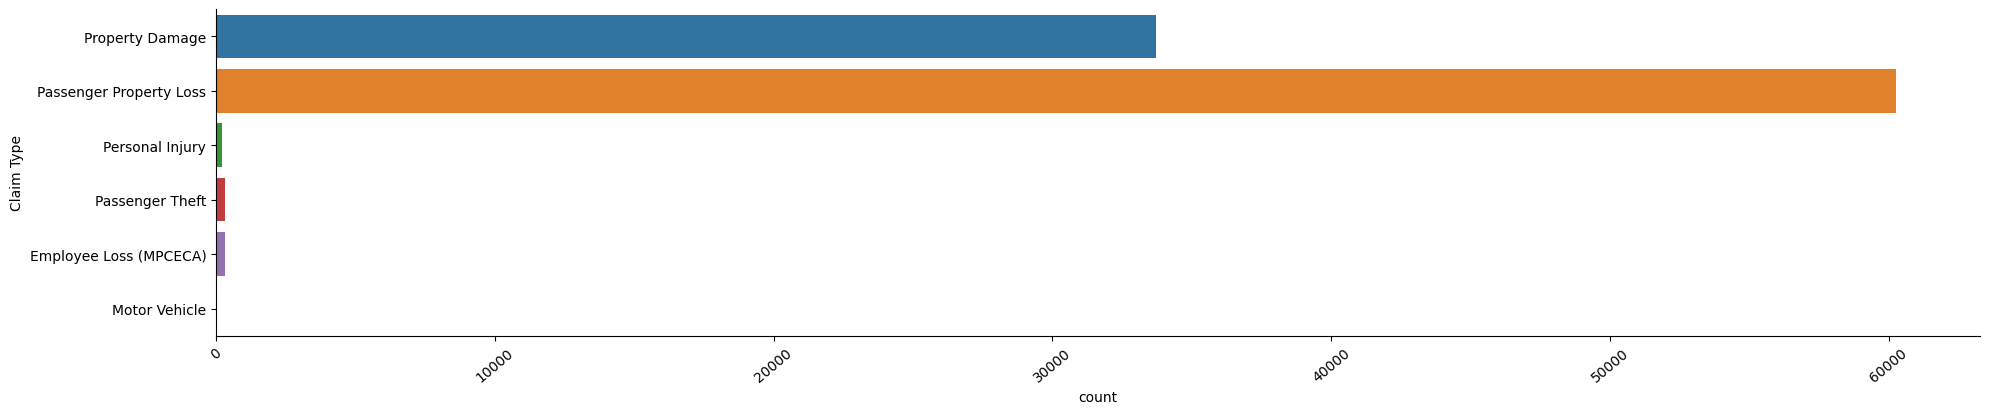

In [51]:
# Question 1
# YOUR CODE HERE
g = sns.catplot(data=claims_df, y='Claim Type', kind='count', hue = 'Claim Type', height = 4, aspect = 5)
for ax in g.axes.flat:
  ax.tick_params(axis='x', rotation=40)

#The most common type of insurance claim that was found had been "Passenger Property Loss" that being things like luggage
#Personal injury is surprisingly low but relatively equal to the numbers that are seen among passenger theft and employee loss

**Summary for Question 1:**

(what does the table or plot tell you?)

## Question 2: Which claim site within the airport are claims most commonly filed for?

*Hint: Same idea, different column.*

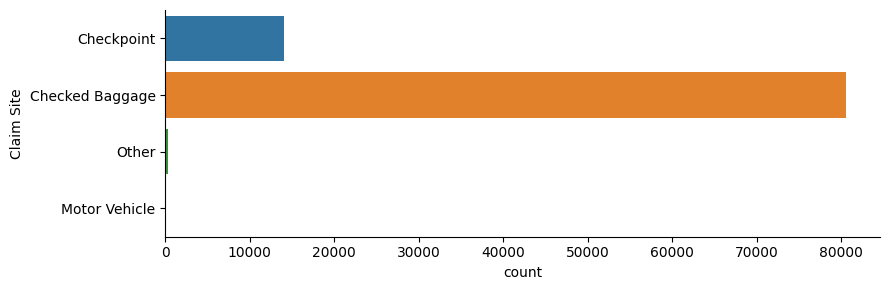

In [60]:
# Question 2
# YOUR CODE HERE
sns.catplot(data=claims_df, y='Claim Site', kind='count', hue = 'Claim Site', height = 3, aspect = 3)
#The "Checked Baggage" claim site within the airport has the most commonly filed for claims

**Summary for Question 2:**

(what does the table or plot tell you?)

## Question 3: What type of claim is made most at each claim site?

*Hint: This one needs two columns at once. Think `groupby()` on the site, then find the most frequent type inside each group. A crosstab is another route.*

In [61]:
# Question 3
# YOUR CODE HERE
claims_df.groupby('Claim Site')['Claim Type'].value_counts()

Claim Site       Claim Type             
Checked Baggage  Passenger Property Loss    53364
                 Property Damage            26527
                 Passenger Theft              294
                 Employee Loss (MPCECA)       275
                 Personal Injury               89
                 Motor Vehicle                  4
Checkpoint       Property Damage             7092
                 Passenger Property Loss     6740
                 Personal Injury              112
                 Passenger Theft               36
                 Employee Loss (MPCECA)        32
                 Motor Vehicle                  1
Motor Vehicle    Passenger Property Loss        2
Other            Passenger Property Loss      159
                 Property Damage              111
                 Personal Injury                7
                 Employee Loss (MPCECA)         1
                 Motor Vehicle                  1
                 Passenger Theft                1
Name: count, dtype: int64

<Axes: xlabel='Claim Site', ylabel='count'>

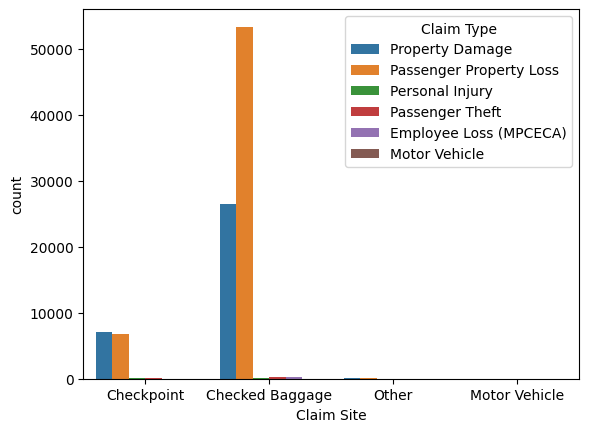

In [68]:
sns.countplot(data=claims_df, x='Claim Site', hue='Claim Type')
#The plot tells me that within the "Checked Baggage" claim site, the claim that is made most are "Passenger Property Loss" which makes sense as this area is essentially meant to deal with this type of stuff
#Within our "Checkpoint" claim site, the claim is made most is "Property Damage" and this makes sense because luggage is handled and checked, where things may be damaged in the process of it all
#Motor Vehicle is extremely low with just 2 passenger property losses

**Summary for Question 3:**

(what does the table or plot tell you?)

## Question 4: What is the typical claim amount?

*Hint: "Typical" is a choice: mean or median? Compute both and explain which one you trust and why. A histogram helps, but watch the scale.*

In [70]:
# Question 4
# YOUR CODE HERE
claims_df.describe().T
#As seen earlier in our mean and median values for typical claim amount

,count,mean,std,min,25%,50%,75%,max
Claim Amount,94848.0,3634.830998,524943.661162,0.0,65.0,183.69,480.6425,125000000.0
Close Amount,94848.0,89.046256,882.058837,0.0,0.0,0.00,61.9725,250000.0


In [ ]:
sns.displot(data=claims_df, kind='hist', x = 'Claim Amount')

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x79630d1a36a0> (for post_execute):


KeyboardInterrupt: 

**Summary for Question 4:**

(what does the table or plot tell you?)

## Question 5: What is the overall claim approval rate for the entire U.S.?

*Hint: You have to define "approved" first. Does Settled count? Say what you decided, then compute the percentage.*

In [30]:
# Question 5
# YOUR CODE HERE
claims_df['Status'].value_counts()

**Summary for Question 5:**

(what does the table or plot tell you?)

## Share-out

Pick the one question your group found most interesting or most surprising. The Presenter will show that table or plot and explain it in under three minutes.

**Question we are presenting:**

**Why:**

## Before you leave

1. Every question has a heading, an answer, and a written summary.
2. Every cleaning decision is explained.
3. Runtime menu, then *Restart and run all*. The whole notebook should run top to bottom without errors.
4. Every group member downloads a copy (File menu, then *Download .ipynb*). You will need this notebook for the final.